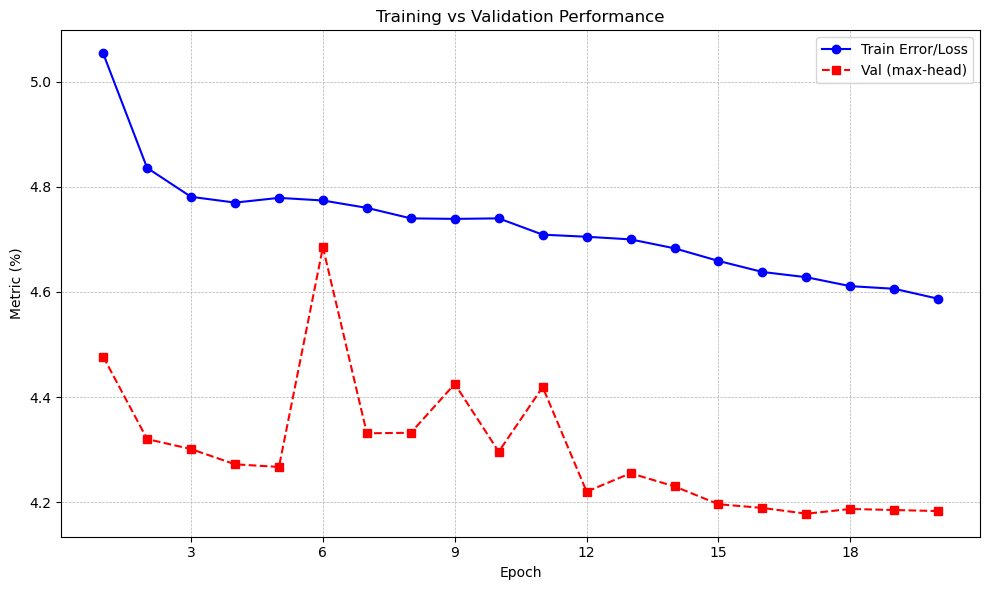

Epoch      | Train      | Val       
-----------------------------------
1          | 5.054      | 4.477     
2          | 4.836      | 4.32      
3          | 4.781      | 4.301     
4          | 4.77       | 4.272     
5          | 4.779      | 4.267     
6          | 4.774      | 4.685     
7          | 4.76       | 4.331     
8          | 4.74       | 4.332     
9          | 4.739      | 4.425     
10         | 4.74       | 4.296     
11         | 4.709      | 4.419     
12         | 4.705      | 4.22      
13         | 4.7        | 4.255     
14         | 4.683      | 4.23      
15         | 4.659      | 4.196     
16         | 4.638      | 4.189     
17         | 4.628      | 4.178     
18         | 4.611      | 4.187     
19         | 4.606      | 4.185     
20         | 4.587      | 4.183     


In [7]:
import re
import matplotlib.pyplot as plt

# 1. READ DATA
# Replace 'training.log' with the path to your actual log file
# If you just want to paste the string directly, assign it to log_content
file_path = 'lvef_regression_0106_v1.log' 

try:
    with open(file_path, 'r') as f:
        log_content = f.read()
except FileNotFoundError:
    print(f"File {file_path} not found. Please create the file or paste logs into a string.")
    log_content = ""

# 2. PARSE DATA
# Regex to find: [INFO...][main] [  1] train: 5.054%  val(max-head): 4.477%
# We capture: Epoch Index, Train Metric, Val Metric
pattern = r"\[main\s*\]\s*\[\s*(\d+)\]\s+train:\s+([\d\.]+)%\s+val\(max-head\):\s+([\d\.]+)%"

data = {} # Using a dict to automatically handle the duplicate lines from multi-GPU

for line in log_content.split('\n'):
    match = re.search(pattern, line)
    if match:
        epoch_idx = int(match.group(1))
        train_metric = float(match.group(2))
        val_metric = float(match.group(3))
        
        # Store in dict to overwrite duplicates (only keeps one entry per epoch)
        data[epoch_idx] = {'train': train_metric, 'val': val_metric}

# 3. ORGANIZE FOR PLOTTING
if not data:
    print("No summary metrics found. Make sure the log contains lines like 'train: X% val(max-head): Y%'")
else:
    epochs = sorted(data.keys())
    train_values = [data[e]['train'] for e in epochs]
    val_values = [data[e]['val'] for e in epochs]

    # 4. PLOT 
    plt.figure(figsize=(10, 6))
    
    # Plot lines
    plt.plot(epochs, train_values, marker='o', linestyle='-', color='blue', label='Train Error/Loss')
    plt.plot(epochs, val_values, marker='s', linestyle='--', color='red', label='Val (max-head)')

    # Formatting
    plt.title('Training vs Validation Performance')
    plt.xlabel('Epoch')
    plt.ylabel('Metric (%)') # Assuming percent based on the "%" in logs
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    
    # Force integer ticks on X-axis if epochs are few
    from matplotlib.ticker import MaxNLocator
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

    # Optional: Print extracted data to console to verify
    print(f"{'Epoch':<10} | {'Train':<10} | {'Val':<10}")
    print("-" * 35)
    for e, t, v in zip(epochs, train_values, val_values):
        print(f"{e:<10} | {t:<10} | {v:<10}")

# Classifier

In [1]:
import re
import matplotlib.pyplot as plt

def extract_accuracies(log_path):
    """
    Extracts per-epoch train and test accuracies from a log file.

    Parameters:
        log_path (str): Path to the log file.

    Returns:
        epochs (list[int]), train_acc (list[float]), test_acc (list[float])
    """
    pattern = re.compile(r"\[\s*(\d+)\]\s+train:\s+([\d.]+)%\s+test:\s+([\d.]+)%")
    epochs, train_acc, test_acc = [], [], []

    with open(log_path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                epoch = int(match.group(1))
                train = float(match.group(2))
                test = float(match.group(3))
                epochs.append(epoch)
                train_acc.append(train)
                test_acc.append(test)

    return epochs, train_acc, test_acc

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Assumes you already have:
# def extract_accuracies(log_path) -> (epochs, train_acc, test_acc)

def ema(values, alpha=0.15):
    s = None
    out = []
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

def plot_runs(
    runs,
    metric="test",          # "test" or "train"
    ema_alpha=0.01,
    dot_alpha=0.02,
    dot_size=20,
    title=None,
    figsize=(11, 6),
    legend_outside=True,
):
    """
    Plot multiple runs as faint dots + opaque EMA line.

    runs: list of (path, label, color)
    metric: "test" or "train"
    """
    assert metric in ("test", "train")
    plt.figure(figsize=figsize)

    mins, maxs = [], []
    for path, label, color in runs:
        if not os.path.exists(path):
            print(f"Warning: missing {path}, skipping.")
            continue

        epochs, train_acc, test_acc = extract_accuracies(path)
        y = test_acc if metric == "test" else train_acc

        # raw dots (same color, translucent)
        plt.scatter(epochs, y, s=dot_size, color=color, alpha=dot_alpha)
        # EMA line (opaque)
        plt.plot(epochs, ema(y, ema_alpha), linewidth=2.5, color=color, label=f"{label} (EMA {ema_alpha})")

        if y:
            mins.append(min(y))
            maxs.append(max(y))

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    if title is None:
        title = f"{metric.capitalize()} Accuracy"
    plt.title(title)
    plt.grid(True, alpha=0.25)

    if legend_outside:
        plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False)
    else:
        plt.legend()

    if mins and maxs:
        plt.ylim(min(mins) - 2, max(maxs) + 2)

    plt.tight_layout()
    plt.show()

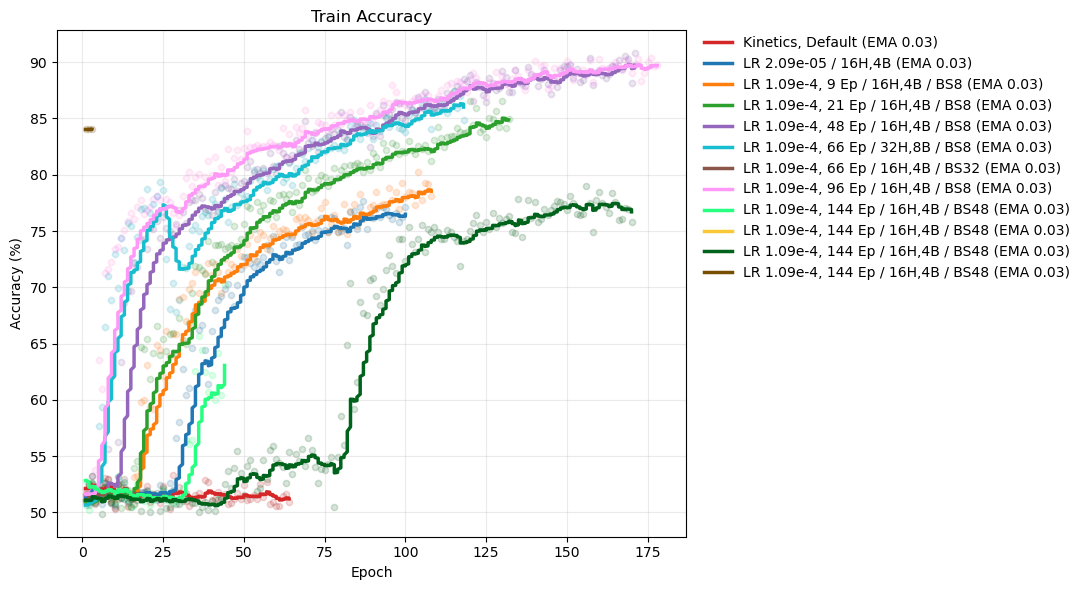

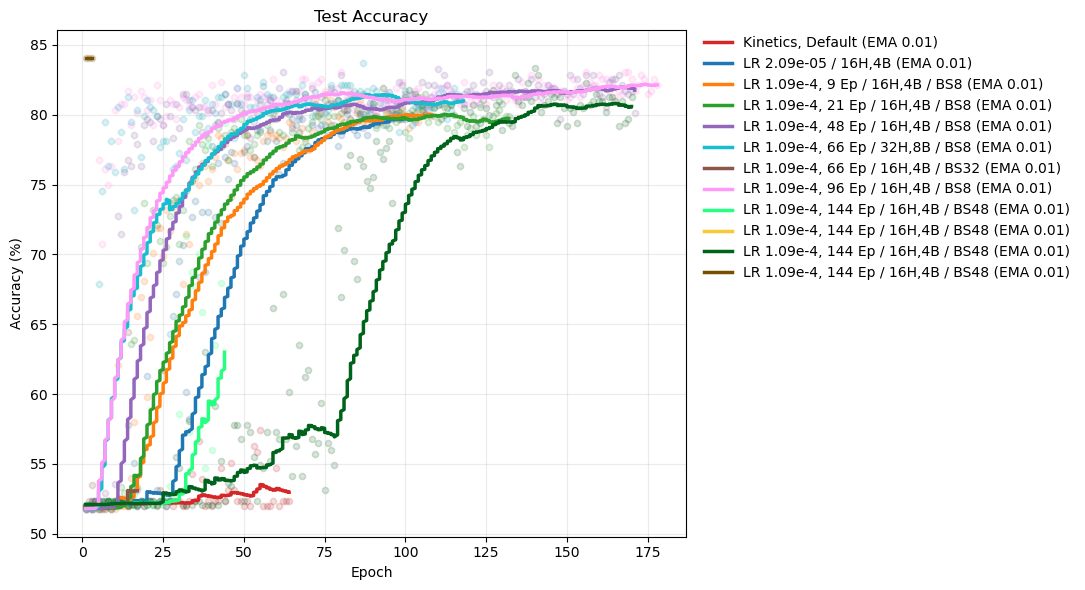

In [6]:

# -------------------- Configure runs once --------------------
BASE = "/home/sagemaker-user/user-default-efs/vjepa2"
runs = [
    (os.path.join(BASE, "rvfx_kinetics_0812_v1.log"),              "Kinetics, Default",              "#d62728"),  # red
    (os.path.join(BASE, "rvfx_cooldown_0812_v1.log"),              "LR 2.09e-05 / 16H,4B",           "#1f77b4"),  # blue
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_0820_keepe9.log"),   "LR 1.09e-4, 9 Ep / 16H,4B / BS8",      "#ff7f0e"),  # orange
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_0820_keepe21.log"),  "LR 1.09e-4, 21 Ep / 16H,4B / BS8",     "#2ca02c"),  # green
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_0820_keepe48.log"),  "LR 1.09e-4, 48 Ep / 16H,4B / BS8",     "#9467bd"),  # purple
    (os.path.join(BASE, "rvfx_cooldown_h32_b8_0820_keepe66.log"),  "LR 1.09e-4, 66 Ep / 32H,8B / BS8",     "#17becf"),  # cyan
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_0823_keepe66.log"),  "LR 1.09e-4, 66 Ep / 16H,4B / BS32", "#8c564b"),# brown
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_0824_keepe96_b8.log"),  "LR 1.09e-4, 96 Ep / 16H,4B / BS8", "#ff99f7"),# pink
    (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826.log"),  "LR 1.09e-4, 144 Ep / 16H,4B / BS48", "#26ff80"),# light green
    (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_FULL.log"),  "LR 1.09e-4, 144 Ep / 16H,4B / BS48", "#fac937"),# yellow
    (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_scaledLR.log"),  "LR 1.09e-4, 144 Ep / 16H,4B / BS48", "#00631b"),# dark green
    (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_FULL_scaledLR.log"),  "LR 1.09e-4, 144 Ep / 16H,4B / BS48", "#784e01"),# dark yellow
]

# -------------------- Make both plots --------------------

# Train accuracy
plot_runs(
    runs,
    metric="train",
    ema_alpha=0.03,
    dot_alpha=0.02,
    dot_size=20,
    title="Train Accuracy",
)


# Test accuracy
plot_runs(
    runs,
    metric="test",
    ema_alpha=0.01,
    dot_alpha=0.02,
    dot_size=20,
    title="Test Accuracy",
)


# Updated Plotting

In [3]:
import os, re
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Regexes (match your log format)
# ============================

# True per-epoch summary lines:
# [   4] train: 51.198% test: 52.083%
EPOCH_RE = re.compile(r"\[\s*(\d+)\]\s+train:\s+([\d.]+)%\s+test:\s+([\d.]+)%")

# In-epoch probe snapshot lines:
# [run_one_epoch] [   42] 85.234% [82.156% 79.891%] [mem: 1.23e+04]
# meaning: iter, BEST, [MEAN MIN], memory (MiB, scientific notation)
STEP_RE = re.compile(
    r"\[run_one_epoch\s*\]\s*\[\s*(\d+)\]\s*([\d.]+)%\s*\[([\d.]+)%\s+([\d.]+)%\]\s*\[mem:\s*([0-9.eE+\-]+)\]"
)

DECODE_FAIL_RE = re.compile(r"Failed to load video:")

# ============================
# Parsers
# ============================

def extract_epoch_metrics_with_step_index(log_path):
    """
    Returns:
      dict(
        epoch: [e1,e2,...],
        train: [.. per-epoch ..],
        test:  [.. per-epoch ..],
        epoch_step_idx: [step index (count of run_one_epoch prints) at time of epoch summary]
      )
    """
    step_idx = 0
    epochs, train, test, epoch_step_idx = [], [], [], []
    with open(log_path, "r", errors="ignore") as f:
        for line in f:
            if STEP_RE.search(line):
                step_idx += 1
                continue
            m = EPOCH_RE.search(line)
            if m:
                epochs.append(int(m.group(1)))
                train.append(float(m.group(2)))
                test.append(float(m.group(3)))
                epoch_step_idx.append(step_idx)
    return {"epoch": epochs, "train": train, "test": test, "epoch_step_idx": epoch_step_idx}

def extract_step_probe_metrics(log_path):
    """
    Returns fine-grained probe stats from in-epoch prints:
      dict(
        step_idx: [0..N-1],
        best:     [],
        mean:     [],
        min:      [],
        mem_gb:   [],   # converted from MiB to GiB
      )
    """
    step_idx, best, mean, minv, mem_gb = [], [], [], [], []
    i = 0
    with open(log_path, "r", errors="ignore") as f:
        for line in f:
            m = STEP_RE.search(line)
            if not m:
                continue
            # m.group(1) is the iter within epoch; we ignore resets and build a monotonic index.
            best.append(float(m.group(2)))
            mean.append(float(m.group(3)))
            minv.append(float(m.group(4)))
            mem_mib = float(m.group(5))
            mem_gb.append(mem_mib / 1024.0)
            step_idx.append(i)
            i += 1
    return {"step_idx": step_idx, "best": best, "mean": mean, "min": minv, "mem_gb": mem_gb}

def count_decode_failures(log_path):
    c = 0
    with open(log_path, "r", errors="ignore") as f:
        for line in f:
            if DECODE_FAIL_RE.search(line):
                c += 1
    return c

# ============================
# Smoothing
# ============================

def ema(values, alpha=0.15):
    s, out = None, []
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

# ============================
# Plotting
# ============================

def plot_epochs(logs, metric="test", ema_alpha=0.03, title=None, figsize=(11,6), legend_outside=True):
    """
    Per-epoch true metrics.
    logs: list[(log_path, label, color)]
    metric: "train" or "test"
    """
    assert metric in ("train", "test")
    plt.figure(figsize=figsize)
    ymins, ymaxs = [], []
    for path, label, color in logs:
        if not os.path.exists(path):
            print(f"Warning: missing {path}, skipping.")
            continue
        d = extract_epoch_metrics_with_step_index(path)
        if not d["epoch"]:
            print(f"Warning: no epoch summaries in {path}")
            continue
        y = d[metric]
        plt.scatter(d["epoch"], y, s=18, color=color, alpha=0.03)
        plt.plot(d["epoch"], ema(y, ema_alpha), lw=2.5, color=color, label=f"{label} (EMA {ema_alpha})")
        ymins.append(min(y)); ymaxs.append(max(y))
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title or f"{metric.capitalize()} Accuracy (per epoch)")
    plt.grid(True, alpha=0.25)
    if legend_outside:
        plt.legend(loc="upper left", bbox_to_anchor=(1.02,1), frameon=False)
    else:
        plt.legend()
    if ymins and ymaxs:
        plt.ylim(min(ymins)-2, max(ymaxs)+2)
    plt.tight_layout()
    plt.show()

In [4]:
def plot_steps_probes_with_true_test(
    logs,  # (path, label, color, per_gpu_bsz[, world_size[, grad_accum]])
    stat="best",
    ema_alpha=0.10,
    show_mem=True,
    title=None,
    figsize=(12,6),
    legend_outside=True,
    default_world_size=None,
    default_grad_accum=1,
    # X-axis controls
    x_tick_step=500_000,     # ticks at 0, 500K, 1000K, ...
    x_max_examples=None,     # hard cap for x-axis (e.g., 1_000_000). None = auto
    # Y-axis controls (accuracy axis)
    y_min=None,              # set explicit min; None = auto
    y_max=None,              # set explicit max; None = auto
    auto_y_pad=2.0,          # padding applied when y_min/y_max are None
):
    """
    Per-step probe stat (EMA, dashed) + epoch-end true test (X markers).
    X-axis = GLOBAL examples = step * (per_gpu_bsz * world_size * grad_accum).
    If world_size / grad_accum are omitted per log tuple, uses defaults/env.
    You can hard-limit X with `x_max_examples`; points beyond are clipped from display.
    You can set Y min/max explicitly; otherwise an automatic padded range is used.
    """
    import os, math
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.ticker import MultipleLocator, FuncFormatter

    EMA_DASH = (0, (2, 2))
    MEM_DOT  = (0, (1, 10))

    # infer defaults from env if not provided
    if default_world_size is None:
        default_world_size = int(os.getenv("WORLD_SIZE") or os.getenv("SLURM_NTASKS") or 1)
    default_grad_accum = max(1, int(default_grad_accum))

    assert stat in ("best", "mean", "min")
    fig, ax1 = plt.subplots(figsize=figsize)

    # Collect series first so we can compute xmax and clip cleanly
    probe_series = []   # (x_step, y, color, label_text)
    epoch_series = []   # (x_epoch, y_epoch, color, label_text)
    mem_series   = []   # (x_step, mem_ema, color)
    ymins, ymaxs = [], []
    max_x_seen   = 0

    def _unpack(entry):
        if len(entry) == 4:
            path, label, color, per_gpu_bsz = entry
            world_size, grad_accum = default_world_size, default_grad_accum
        elif len(entry) == 5:
            path, label, color, per_gpu_bsz, world_size = entry
            grad_accum = default_grad_accum
        else:
            path, label, color, per_gpu_bsz, world_size, grad_accum = entry[:6]
        return path, label, color, int(per_gpu_bsz), int(world_size), int(grad_accum)

    for entry in logs:
        path, label, color, per_gpu_bsz, world_size, grad_accum = _unpack(entry)
        if not os.path.exists(path):
            print(f"Missing {path}, skipping.")
            continue

        step  = extract_step_probe_metrics(path)
        epoch = extract_epoch_metrics_with_step_index(path)

        eff_bsz = per_gpu_bsz * max(1, world_size) * max(1, grad_accum)

        x_step  = [s * eff_bsz for s in step["step_idx"]]
        x_epoch = [s * eff_bsz for s in epoch["epoch_step_idx"]]
        if x_step:  max_x_seen = max(max_x_seen, x_step[-1])
        if x_epoch: max_x_seen = max(max_x_seen, x_epoch[-1])

        if step["step_idx"]:
            y = step[stat]
            probe_series.append((x_step, y, color, f"{label} (probe {stat}, EMA)"))
            ymins.append(min(y)); ymaxs.append(max(y))
            if show_mem and "mem_gb" in step and step["mem_gb"]:
                mem_series.append((x_step, ema(step["mem_gb"], 0.10), color))

        if epoch["epoch_step_idx"]:
            y = epoch["test"]
            epoch_series.append((x_epoch, y, color, f"{label} (test @ epoch end)"))
            ymins.append(min(y)); ymaxs.append(max(y))

    # Determine x-range and formatter (0, 500K, 1000K, …)
    xmax_auto = math.ceil((max_x_seen or x_tick_step) / x_tick_step) * x_tick_step
    xmax = x_max_examples if x_max_examples is not None else xmax_auto
    ax1.set_xlim(0, xmax)
    ax1.xaxis.set_major_locator(MultipleLocator(base=x_tick_step))
    ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: "0" if abs(x) < 1e-9 else f"{int(round(x/1000.0))}K"))

    # Helper to clip series to x<=xmax
    def _clip_xy(x, y, lim):
        if not x:
            return [], []
        x_arr = np.asarray(x)
        y_arr = np.asarray(y)
        m = x_arr <= lim
        return x_arr[m].tolist(), y_arr[m].tolist()

    # Plot probe EMA (dashed)
    handles, labels_txt = [], []
    for x, y, color, lbl in probe_series:
        x_c, y_c = _clip_xy(x, y, xmax)
        if not x_c: continue
        ln, = ax1.plot(
            x_c, ema(y_c, ema_alpha),
            lw=1.2, color=color, alpha=0.9,
            linestyle=EMA_DASH, dash_capstyle="butt",
            label=lbl
        )
        handles.append(ln); labels_txt.append(lbl)

    # Plot epoch-end tests (X markers only)
    for x, y, color, lbl in epoch_series:
        x_c, y_c = _clip_xy(x, y, xmax)
        if not x_c: continue
        sc = ax1.scatter(
            x_c, y_c,
            s=100, marker="x", color=color,
            linewidths=2.5, edgecolors="k", zorder=10,
            label=lbl
        )
        handles.append(sc); labels_txt.append(lbl)

    # Optional GPU memory on twin axis
    if show_mem:
        ax2 = ax1.twinx()
        for x, y, color in mem_series:
            x_c, y_c = _clip_xy(x, y, xmax)
            if not x_c: continue
            ax2.plot(
                x_c, y_c,
                lw=1.0, color=color, alpha=0.18,
                linestyle=MEM_DOT, dash_capstyle="butt"
            )
        ax2.set_ylabel("GPU Memory (GiB)", rotation=270, labelpad=14)
        ax2.set_xlim(0, xmax)

    # Axes labels, title, grid
    ax1.set_xlabel("Examples seen (global)")
    ax1.set_ylabel("Accuracy (%)")
    ax1.set_title(title or f"Probe {stat} (granular) + true test @ epoch end")
    ax1.grid(True, alpha=0.25)

    # Legend (dedup)
    by_label = dict(zip(labels_txt, handles))
    if legend_outside:
        ax1.legend(by_label.values(), by_label.keys(),
                   loc="upper left", bbox_to_anchor=(1.02,1), frameon=False)
    else:
        ax1.legend(by_label.values(), by_label.keys())

    # Y-limits (accuracy axis)
    if y_min is not None or y_max is not None:
        if ymins and ymaxs:
            ymin_auto = min(ymins) - auto_y_pad
            ymax_auto = max(ymaxs) + auto_y_pad
            ax1.set_ylim(
                y_min if y_min is not None else ymin_auto,
                y_max if y_max is not None else ymax_auto,
            )
    else:
        if ymins and ymaxs:
            ax1.set_ylim(min(ymins) - auto_y_pad, max(ymaxs) + auto_y_pad)

    plt.tight_layout()
    plt.show()


In [5]:
def _unique_epoch_metrics(e):
    """
    Deduplicate epoch summaries by epoch id, keeping the LAST entry per epoch.
    Returns the same dict schema as input, but with unique, sorted epochs.
    """
    buf = {}  # epoch -> (train, test, epoch_step_idx)
    for ep, tr, te, st in zip(e["epoch"], e["train"], e["test"], e["epoch_step_idx"]):
        buf[int(ep)] = (float(tr), float(te), int(st))  # last occurrence wins
    ep_sorted = sorted(buf.keys())
    train_u   = [buf[ep][0] for ep in ep_sorted]
    test_u    = [buf[ep][1] for ep in ep_sorted]
    step_u    = [buf[ep][2] for ep in ep_sorted]
    return {"epoch": ep_sorted, "train": train_u, "test": test_u, "epoch_step_idx": step_u}

def summarize_log(log_path):
    e = extract_epoch_metrics_with_step_index(log_path)
    s = extract_step_probe_metrics(log_path)

    # dedupe epochs
    e_u = _unique_epoch_metrics(e)

    # epochs: count unique or take max epoch id
    n_epochs_unique = len(e_u["epoch"])
    max_epoch_id    = (e_u["epoch"][-1] if e_u["epoch"] else 0)

    # steps: total [run_one_epoch] lines (train + val snapshots)
    n_steps = len(s["step_idx"])

    # iterations-per-epoch estimate from epoch_step_idx deltas
    import numpy as np
    if len(e_u["epoch_step_idx"]) >= 2:
        ipe_est = int(np.median(np.diff(e_u["epoch_step_idx"])))
    else:
        ipe_est = 0

    last_test = (e_u["test"][-1] if e_u["test"] else float("nan"))
    fails = count_decode_failures(log_path)

    print(
        f"{os.path.basename(log_path)} | steps={n_steps} "
        f"| epochs(unique)={n_epochs_unique} | max_epoch={max_epoch_id} "
        f"| ipe≈{ipe_est} | last_test={last_test:.2f}% | decode_failures={fails}"
    )


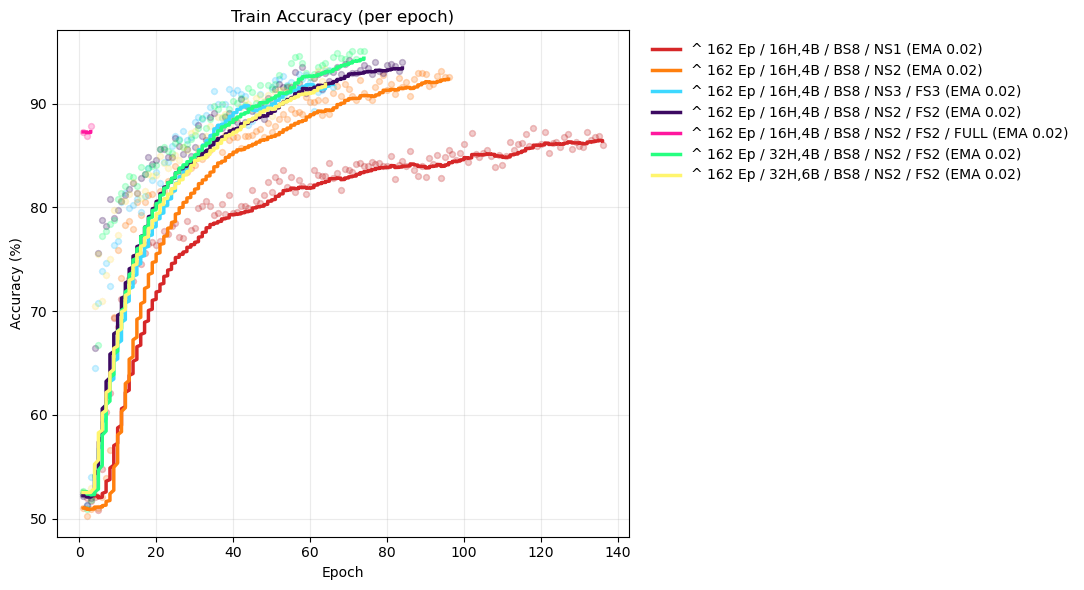

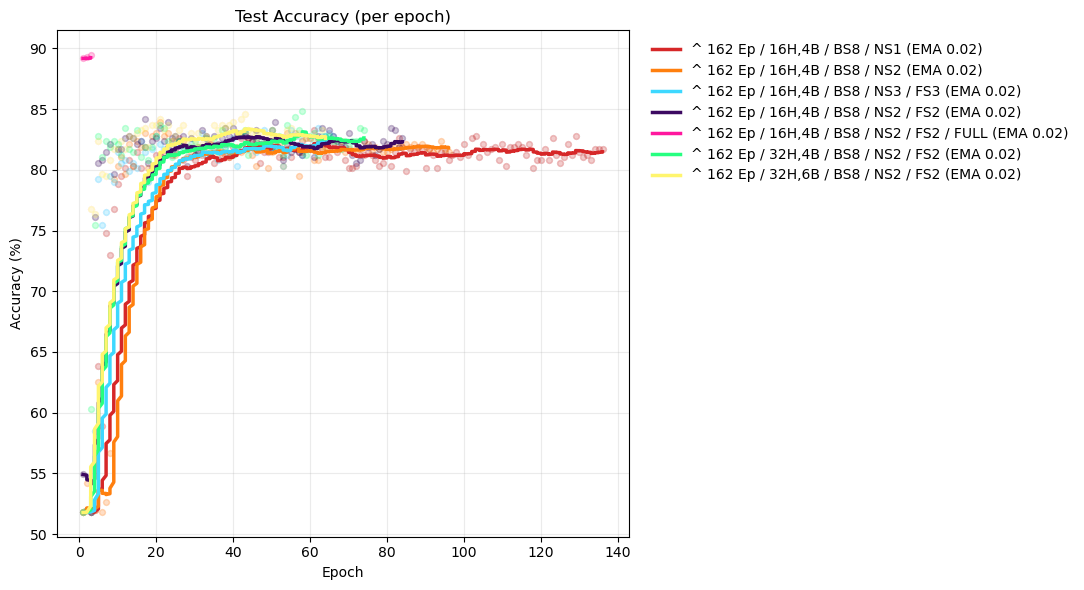

In [90]:
#-------------------- Configure runs once --------------------
# # -------------------- Configure runs once --------------------
# BASE = "/home/sagemaker-user/user-default-efs/vjepa2"
# runs = [
#     # (os.path.join(BASE, "rvfx_kinetics_0812_v1.log"),                 "Kinetics, Default",                          "#d62728"),  # red
#     # (os.path.join(BASE, "rvfx_cooldown_0812_v1.log"),                 "LR 2.09e-05 / 16H,4B",                       "#1f77b4"),  # blue
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_0820_keepe9.log"),      "LR 1.09e-4, 9 Ep / 16H,4B / BS8",            "#ff7f0e"),  # orange
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_0820_keepe21.log"),     "^ 21 Ep / 16H,4B / BS8",           "#2ca02c"),  # green
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_0820_keepe48.log"),     "^ 48 Ep / 16H,4B / BS8",           "#9467bd"),  # purple
#     # (os.path.join(BASE, "rvfx_cooldown_h32_b8_0820_keepe66.log"),     "^ 66 Ep / 32H,8B / BS8",           "#17becf"),  # cyan
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_0823_keepe66.log"),     "^ 66 Ep / 16H,4B / BS32",          "#8c564b"),  # brown
#     (os.path.join(BASE, "rvfx_cooldown_h16_b4_0824_keepe96_b8.log"),  "^ 96 Ep / 16H,4B / BS8",           "#ff99f7"),  # pink
#     (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826.log"),  "^ 144 Ep / 16H,4B / BS48",         "#26ff80"),  # light green
#     (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_FULL.log"), "^ 144 Ep / 16H,4B / BS48 / FULL",     "#fac937"),  # yellow
#     (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_scaledLR.log"),  "^ 144 Ep / 16H,4B / BS48 / xLR",         "#0f5923"),  # dark green
#     (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_FULL_scaledLR.log"), "^ 144 Ep / 16H,4B / BS48 / xLR / FULL",     "#a36502"),  # dark yellow
# ]


BASE = "/home/sagemaker-user/user-default-efs/vjepa2"
runs = [
    # (os.path.join(BASE, "rvfx_cooldown_0812_v1.log"),                 "LR 2.09e-05 / 16H,4B",                       "#1f77b4"),  # blue
    # (os.path.join(BASE, "rvfx_cooldown_h16_b4_0824_keepe96_b8.log"),  "^ 96 Ep / 16H,4B / BS8",           "#ff99f7"),  # pink
    # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826.log"),  "^ 144 Ep / 16H,4B / BS48",         "#26ff80"),  # light green
    # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_scaledLR.log"),  "^ 144 Ep / 16H,4B / BS48 / xLR",         "#0f5923"),  # dark green
    # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0827_scaledLR_v2.log"), "^ 141 Ep / 16H,4B / BS48 / xLR2",  "#1f77b4"),  # blue
    # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0827_scaledLR_v3.log"), "^ 141 Ep / 16H,4B / BS48 / xLR3", "#fac937"),  # purple
    # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_FULL.log"), "^ 144 Ep / 16H,4B / BS48 / FULL",     "#fac937"),  # yellow
    # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_FULL_scaledLR.log"), "^ 144 Ep / 16H,4B / BS48 / xLR / FULL",     "#a36502"),  # dark yellow
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0827_ns1.log"), "^ 162 Ep / 16H,4B / BS8 / NS1",     "#d62728"),  #  red
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0827_ns2.log"), "^ 162 Ep / 16H,4B / BS8 / NS2",     "#ff7f0e"),  #  orange
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0827_fs3_ns3.log"), "^ 162 Ep / 16H,4B / BS8 / NS3 / FS3",     "#3dd8ff"),  #  light blue
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0828_fs2_ns2.log"), "^ 162 Ep / 16H,4B / BS8 / NS2 / FS2",     "#3c0961"),  #  purple
    (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0828_fs2_ns2_FULL.log"), "^ 162 Ep / 16H,4B / BS8 / NS2 / FS2 / FULL",     "#ff179e"),  #  hot pink
    (os.path.join(BASE, "rvfx_cooldown_h32_b4_bs8_ep162_0828_fs2_ns2.log"), "^ 162 Ep / 32H,4B / BS8 / NS2 / FS2",     "#26ff80"),  #  light green
    (os.path.join(BASE, "rvfx_cooldown_h32_b6_bs8_ep162_0828_fs2_ns2.log"), "^ 162 Ep / 32H,6B / BS8 / NS2 / FS2",     "#fff56e"),  #  pink
    # (os.path.join(BASE, "rvfx_cooldown_h44_b4_bs8_ep162_0828_fs2_ns2.log"), "^ 162 Ep / 44H,4B / BS8 / NS2 / FS2",     "#1f77b4"),  #  blue
]

# -------------------- Epoch-level plots (as before, but new parser) --------------------
plot_epochs(
    runs,
    metric="train",
    ema_alpha=0.02,
    title="Train Accuracy (per epoch)",
)

plot_epochs(
    runs,
    metric="test",
    ema_alpha=0.02,   # a touch higher for smoother epoch lines
    title="Test Accuracy (per epoch)",
)


In [72]:
# full_runs = [
#         # (os.path.join(BASE, "rvfx_cooldown_0812_v1.log"),                 "LR 2.09e-05 / 16H,4B",                       "#1f77b4"),  # blue
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_0824_keepe96_b8.log"),  "^ 96 Ep / 16H,4B / BS8",           "#ff99f7"),  # pink
#     # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826.log"),  "^ 144 Ep / 16H,4B / BS48",         "#26ff80"),  # light green
#     # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_scaledLR.log"),  "^ 144 Ep / 16H,4B / BS48 / xLR",         "#0f5923"),  # dark green
#     # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0827_scaledLR_v2.log"), "^ 141 Ep / 16H,4B / BS48 / xLR2",  "#1f77b4"),  # blue
#     # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0827_scaledLR_v3.log"), "^ 141 Ep / 16H,4B / BS48 / xLR3", "#fac937"),  # purple
    
    
    
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0827_ns1.log"), "^ 162 Ep / 16H,4B / BS8 / NS1",     "#d62728"),  #  red
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0827_ns2.log"), "^ 162 Ep / 16H,4B / BS8 / NS2",     "#ff7f0e"),  #  orange
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0827_fs3_ns3.log"), "^ 162 Ep / 16H,4B / BS8 / NS3 / FS3",     "#3dd8ff"),  #  light blue
#     # (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0828_fs2_ns2.log"), "^ 162 Ep / 16H,4B / BS8 / NS2 / FS2",     "#3c0961"),  #  purple
#     # (os.path.join(BASE, "rvfx_cooldown_h32_b4_bs8_ep162_0828_fs2_ns2.log"), "^ 162 Ep / 32H,4B / BS8 / NS2 / FS2",     "#26ff80"),  #  light green
    
#     # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_FULL.log"), "^ 144 Ep / 16H,4B / BS48 / FULL",     "#fac937"),  # yellow
#     # (os.path.join(BASE, "rvfx_kinetics_h16_b4_bs48_ep144_0826_FULL_scaledLR.log"), "^ 144 Ep / 16H,4B / BS48 / xLR / FULL",     "#a36502"),  # dark yellow
    
#     (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0828_fs2_ns2_FULL.log"), "^ 162 Ep / 16H,4B / BS8 / NS2 / FS2 / FULL",     "#ff179e", 8),  #  hot pink
#     # (os.path.join(BASE, "rvfx_cooldown_h44_b4_bs8_ep162_0828_fs2_ns2.log"), "^ 162 Ep / 44H,4B / BS8 / NS2 / FS2 / FULL",     "#0f5923"),  #  yellow
#     # (os.path.join(BASE, "rvfx_bs8_ns2_pt200_0830_v2.log"), "^ 200 PT / 16H,4B / BS8 / NS2 / FS2 / FULL ",     "#ff99f7"),  #  pink
#     # (os.path.join(BASE, "rvfx_bs8_ns2_anneal27_0830_v2.log"), "^ 27 Anneal / 16H,4B / BS8 / NS2 / FS2 / FULL",     "#1f77b4"),  #  blue
#     # (os.path.join(BASE, "rvfx_h32_b6_0831.log"), "^ 162 Ep / 32H,6B / BS8 / NS2 / FS2 / FULL",     "#26ff80"),  #  light green

#     # rvfx_bs8_ns2_anneal39_ssv2_0905.log
#     (os.path.join(BASE, "rvfx_bs8_ns2_anneal39_ssv2_0905.log"), "^ 39 An / 16H,4B / BS2 / FS1 / NS2 / NV2 / FPC32 / FULL",     "#d62728", 2),  #  red
#     (os.path.join(BASE, "rvfx_bs8_ns2_pretrain198_ssv2_0905.log"), "^ 198 Pt / 16H,4B / BS2 / FS1 / NS3 / NV2 / FPC16 / FULL",     "#3c0961", 2),  #  purple
# ]


/tmp/ipykernel_2851/833527664.py:121: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  sc = ax1.scatter(


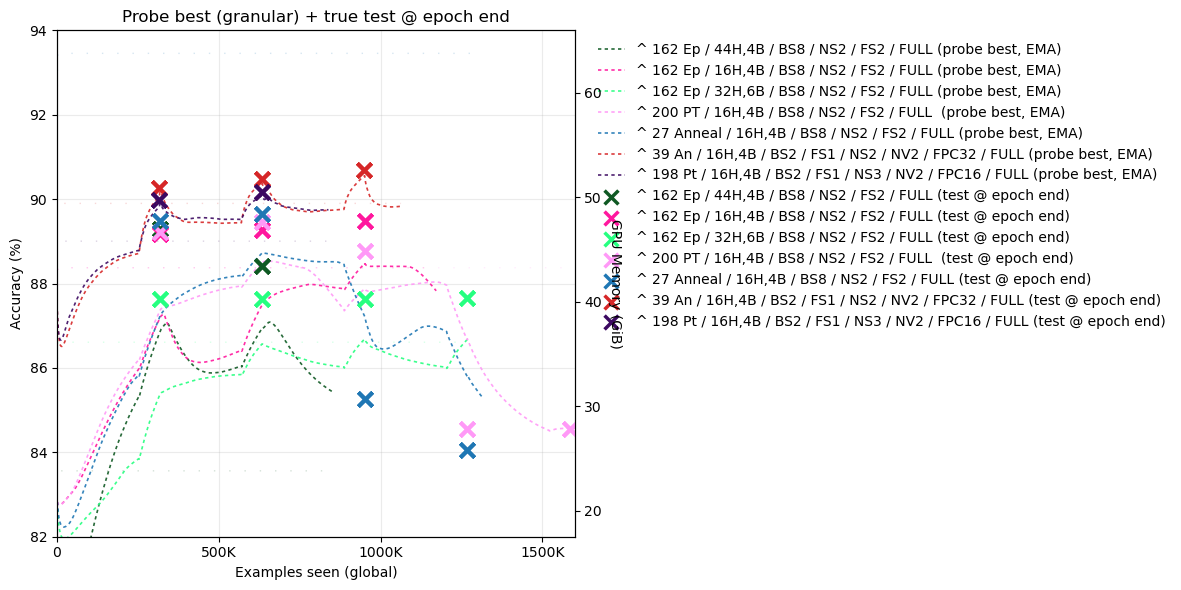

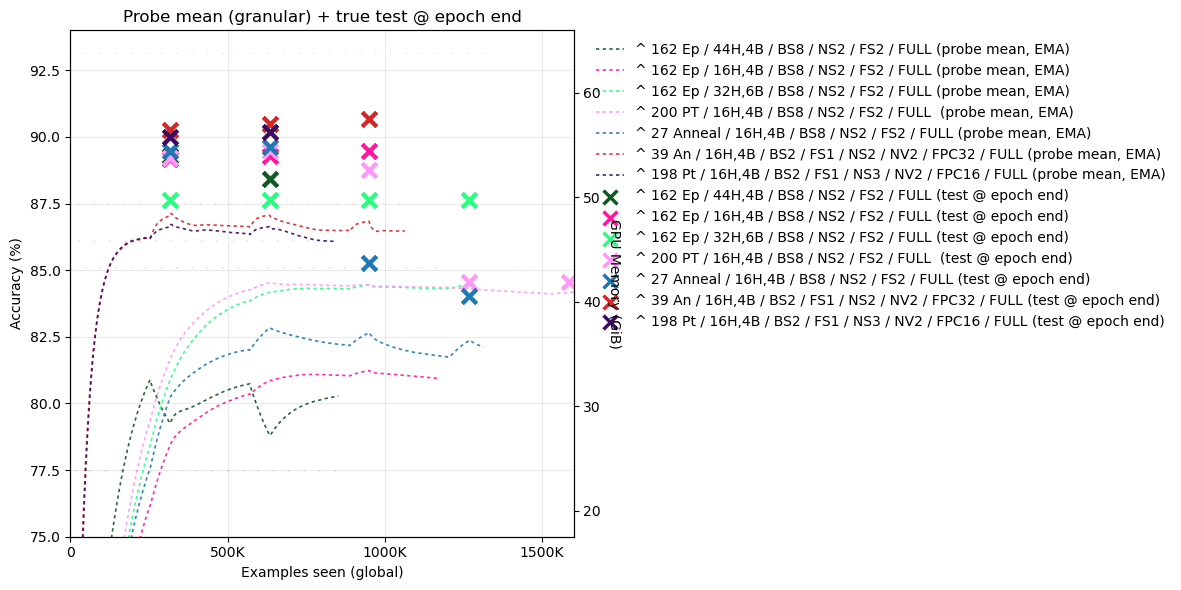

In [162]:
full_runs = [
    (os.path.join(BASE, "rvfx_cooldown_h44_b4_bs8_ep162_0828_fs2_ns2.log"), "^ 162 Ep / 44H,4B / BS8 / NS2 / FS2 / FULL",     "#0f5923", 8),  #  yellow

    (os.path.join(BASE, "rvfx_cooldown_h16_b4_bs8_ep162_0828_fs2_ns2_FULL.log"), "^ 162 Ep / 16H,4B / BS8 / NS2 / FS2 / FULL",     "#ff179e", 8),  #  hot pink
    (os.path.join(BASE, "rvfx_h32_b6_0831.log"), "^ 162 Ep / 32H,6B / BS8 / NS2 / FS2 / FULL",     "#26ff80", 8),  #  light green

    (os.path.join(BASE, "rvfx_bs8_ns2_pt200_0830_v2.log"), "^ 200 PT / 16H,4B / BS8 / NS2 / FS2 / FULL ",     "#ff99f7", 8),  #  pink
    (os.path.join(BASE, "rvfx_bs8_ns2_anneal27_0830_v2.log"), "^ 27 Anneal / 16H,4B / BS8 / NS2 / FS2 / FULL",     "#1f77b4", 8),  #  blue

    (os.path.join(BASE, "rvfx_bs8_ns2_anneal39_ssv2_0905.log"), "^ 39 An / 16H,4B / BS2 / FS1 / NS2 / NV2 / FPC32 / FULL",     "#d62728", 2),  #  red
    (os.path.join(BASE, "rvfx_bs8_ns2_pretrain198_ssv2_0905.log"), "^ 198 Pt / 16H,4B / BS2 / FS1 / NS3 / NV2 / FPC16 / FULL",     "#3c0961", 2),  #  purple
]


# -------------------- Step-level (granular) plots --------------------
# Great for early training when epoch summaries are sparse.
# Probe BEST per step + true test (epoch-end)
plot_steps_probes_with_true_test(
    full_runs,
    stat="best",
    ema_alpha=0.0005,
    show_mem=True,
    title="Probe best (granular) + true test @ epoch end",
    default_world_size=8, default_grad_accum=1,
    x_tick_step=500_000,     # tick every 500K: 0, 500K, 1000K, ...
    x_max_examples=1_600_000,     # hard cap for x-axis (e.g., 1_000_000). None = auto
    y_min=82, y_max=94
)

# Probe MEAN per step + true test (epoch-end)
plot_steps_probes_with_true_test(
    full_runs,
    stat="mean",
    ema_alpha=0.0005,
    show_mem=True,
    title="Probe mean (granular) + true test @ epoch end",
    default_world_size=8, default_grad_accum=1,
    x_tick_step=500_000,     # tick every 500K: 0, 500K, 1000K, ...
    x_max_examples=1_600_000,     # hard cap for x-axis (e.g., 1_000_000). None = auto
    y_min=75, y_max=94
)

In [160]:
# -------------------- Quick console summaries --------------------
for path, label, *_ in runs:
    if os.path.exists(path):
        print(f"\n== {label} ==")
        summarize_log(path)
    else:
        print(f"\n== {label} == (missing: {path})")

for path, label, *_ in full_runs:
    if os.path.exists(path):
        print(f"\n== {label} ==")
        summarize_log(path)
    else:
        print(f"\n== {label} == (missing: {path})")



== ^ 162 Ep / 16H,4B / BS8 / NS1 ==
rvfx_cooldown_h16_b4_bs8_ep162_0827_ns1.log | steps=5440 | epochs(unique)=136 | max_epoch=136 | ipe≈40 | last_test=81.70% | decode_failures=136

== ^ 162 Ep / 16H,4B / BS8 / NS2 ==
rvfx_cooldown_h16_b4_bs8_ep162_0827_ns2.log | steps=3840 | epochs(unique)=96 | max_epoch=96 | ipe≈40 | last_test=81.47% | decode_failures=96

== ^ 162 Ep / 16H,4B / BS8 / NS3 / FS3 ==
rvfx_cooldown_h16_b4_bs8_ep162_0827_fs3_ns3.log | steps=2640 | epochs(unique)=66 | max_epoch=66 | ipe≈40 | last_test=82.81% | decode_failures=66

== ^ 162 Ep / 16H,4B / BS8 / NS2 / FS2 ==
rvfx_cooldown_h16_b4_bs8_ep162_0828_fs2_ns2.log | steps=3360 | epochs(unique)=84 | max_epoch=84 | ipe≈40 | last_test=82.59% | decode_failures=84

== ^ 162 Ep / 16H,4B / BS8 / NS2 / FS2 / FULL ==
rvfx_cooldown_h16_b4_bs8_ep162_0828_fs2_ns2_FULL.log | steps=18312 | epochs(unique)=3 | max_epoch=3 | ipe≈4952 | last_test=89.49% | decode_failures=7

== ^ 162 Ep / 32H,4B / BS8 / NS2 / FS2 ==
rvfx_cooldown_h32_b4_b

# Pacemaker

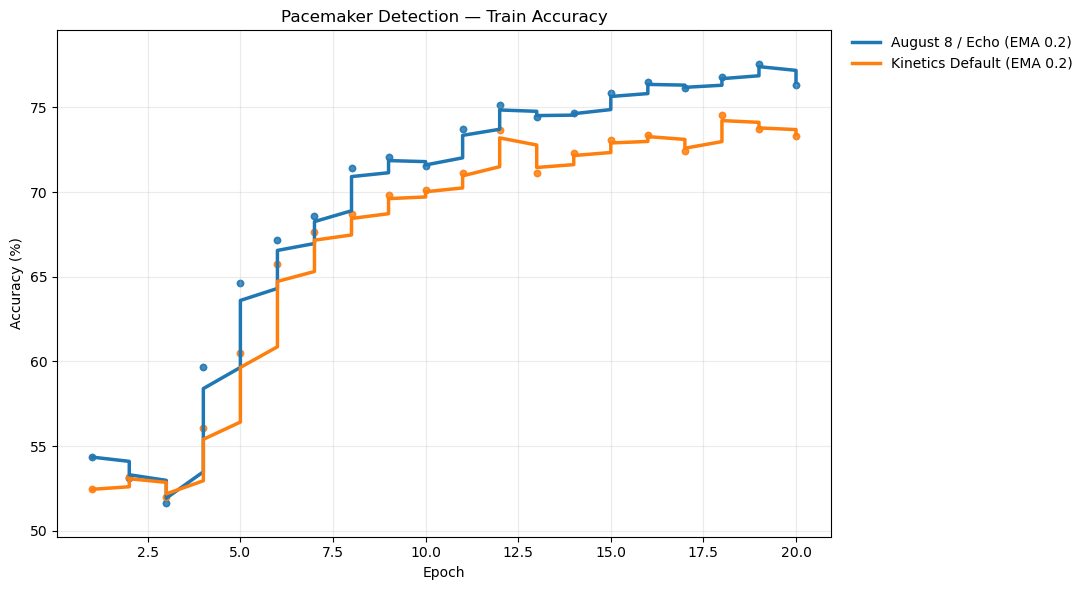

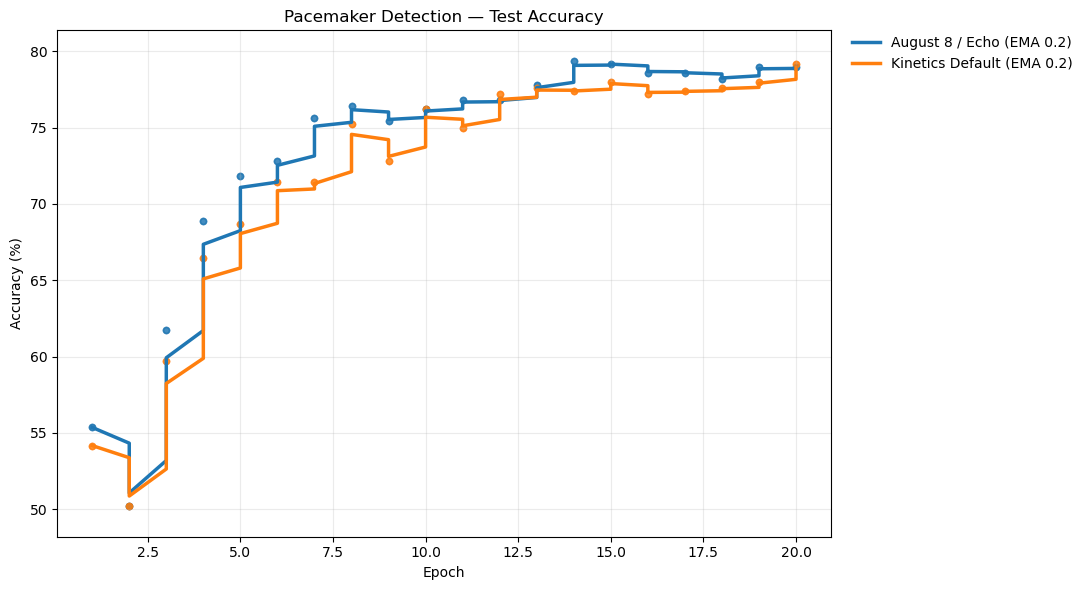

In [7]:
# Reuse your existing functions: extract_accuracies, ema, and plot_runs

import os

BASE = "/home/sagemaker-user/user-default-efs/vjepa2"

# Configure Pacemaker runs once
runs_pace = [
    (os.path.join(BASE, "pacemaker_cooldown_0808_v1.log"), "August 8 / Echo",   "#1f77b4"),  # blue
    (os.path.join(BASE, "pacemaker_kinetics_0808_v1.log"), "Kinetics Default",  "#ff7f0e"),  # orange
    # Uncomment to add more:
    # (os.path.join(BASE, "pacemaker_cooldown_0809_v2.log"), "Cooldown 0809 v2", "#2ca02c"),
    # (os.path.join(BASE, "pacemaker_cooldown_v2.log"),      "Cooldown v2",      "#9467bd"),
    # (os.path.join(BASE, "pacemaker_kinetics_0809_v2.log"), "Kinetics 0809 v2", "#d62728"),
]

# Train accuracy
plot_runs(
    runs_pace,
    metric="train",
    ema_alpha=0.20,
    dot_alpha=0.20,
    dot_size=20,
    title="Pacemaker Detection — Train Accuracy",
    figsize=(11, 6),
    legend_outside=True,
)

# Test accuracy
plot_runs(
    runs_pace,
    metric="test",
    ema_alpha=0.20,
    dot_alpha=0.20,
    dot_size=20,
    title="Pacemaker Detection — Test Accuracy",
    figsize=(11, 6),
    legend_outside=True,
)


# Pretraining

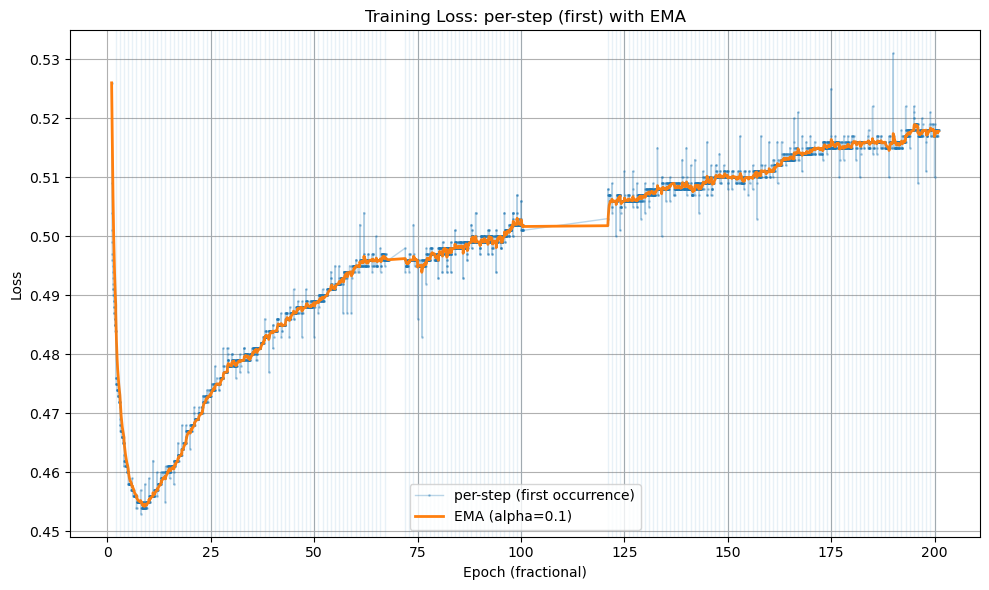

In [8]:
import re
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt

# Paths to both logs
LOG_FILES = [
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep0-34-0820.log",
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep34-100-0820.log",
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep66-100-0822.log",
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep78-100-0822.log",
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep78-100-0822.log",
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep96-200-0824.log",
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep120-200-0825.log"
]

ALPHA = 0.10  # EMA smoothing factor

# Regex for step losses
STEP_PAT = re.compile(r"\[(\d+),\s*(\d+)\]\s+loss:\s+([0-9]*\.?[0-9]+)")

def extract_first_loss_per_step(log_path):
    """
    Return list of (epoch, step, loss) for the FIRST occurrence of each (epoch, step).
    """
    first = OrderedDict()
    with open(log_path, "r") as f:
        for line in f:
            m = STEP_PAT.search(line)
            if not m:
                continue
            e, s, l = int(m.group(1)), int(m.group(2)), float(m.group(3))
            key = (e, s)
            if key not in first:
                first[key] = l
    return [(e, s, l) for (e, s), l in first.items()]

def ema(values, alpha=0.01):
    """Exponential moving average (continuous across the run)."""
    out, s = [], None
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

# ---- parse both logs and combine ----
all_records = []
for path in LOG_FILES:
    all_records.extend(extract_first_loss_per_step(path))

# sort by epoch, step
all_records = sorted(all_records, key=lambda x: (x[0], x[1]))
epochs, steps, losses = zip(*all_records)

# fractional epoch x-axis
max_step = max(steps)
x_steps = [e + s / (max_step + 1.0) for e, s in zip(epochs, steps)]

# compute EMA
losses_ema = ema(losses, alpha=ALPHA)

# ---- plot ----
plt.figure(figsize=(10, 6))
plt.plot(
    x_steps, losses,
    marker=".", linestyle="-",
    linewidth=1, markersize=2,
    alpha=0.3,
    # color="#808080",   # gray per-step
    label="per-step (first occurrence)"
)
plt.plot(
    x_steps, losses_ema,
    linewidth=2,
    # color="#1f77b4",   # blue EMA
    label=f"EMA (alpha={ALPHA})"
)

# epoch boundary lines
for e in sorted(set(epochs))[1:]:
    plt.axvline(e, alpha=0.1, linewidth=1)

plt.xlabel("Epoch (fractional)")
plt.ylabel("Loss")
plt.title("Training Loss: per-step (first) with EMA")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Anneal

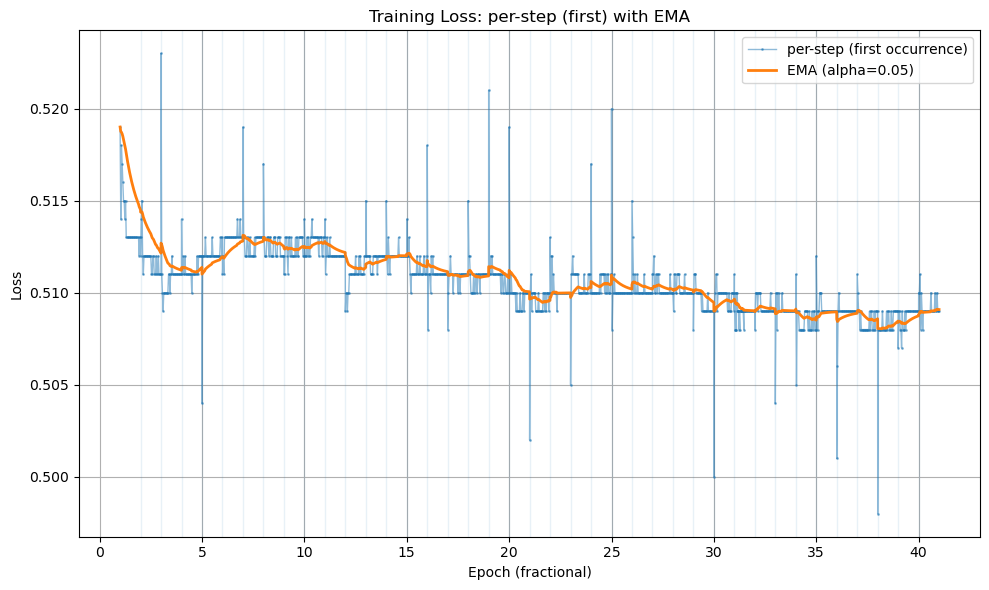

In [13]:
import re
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt

# Paths to both logs
LOG_FILES = [
    "cooldown-echo-336px-32f-ep200-0828.log",
    "cooldown-echo-336px-32f-ep200-ep31-0828.log"
]

ALPHA = 0.05  # EMA smoothing factor

# Regex for step losses
STEP_PAT = re.compile(r"\[(\d+),\s*(\d+)\]\s+loss:\s+([0-9]*\.?[0-9]+)")

# ---- parse both logs and combine ----
all_records = []
for path in LOG_FILES:
    all_records.extend(extract_first_loss_per_step(path))

# sort by epoch, step
all_records = sorted(all_records, key=lambda x: (x[0], x[1]))
epochs, steps, losses = zip(*all_records)

# fractional epoch x-axis
max_step = max(steps)
x_steps = [e + s / (max_step + 1.0) for e, s in zip(epochs, steps)]

# compute EMA
losses_ema = ema(losses, alpha=ALPHA)

# ---- plot ----
plt.figure(figsize=(10, 6))
plt.plot(
    x_steps, losses,
    marker=".", linestyle="-",
    linewidth=1, markersize=2,
    alpha=0.5,
    # color="#808080",   # gray per-step
    label="per-step (first occurrence)"
)
plt.plot(
    x_steps, losses_ema,
    linewidth=2,
    # color="#1f77b4",   # blue EMA
    label=f"EMA (alpha={ALPHA})"
)

# epoch boundary lines
for e in sorted(set(epochs))[1:]:
    plt.axvline(e, alpha=0.1, linewidth=1)

plt.xlabel("Epoch (fractional)")
plt.ylabel("Loss")
plt.title("Training Loss: per-step (first) with EMA")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
import re
from collections import OrderedDict

# Paths to your log
LOG_FILES = [
    "/home/sagemaker-user/user-default-efs/vjepa2/vjepa_train-55.out"
]

# ==========================================
# 1. UPDATED REGEX
# ==========================================
# Matches: ... [run_one_epoch] [ 3240] 4.246 ...
# Group 1: Step (e.g., 3240)
# Group 2: Loss/Value (e.g., 4.246)
STEP_PAT = re.compile(r"\[run_one_epoch\s*\]\s*\[\s*(\d+)\]\s*([0-9]*\.?[0-9]+)")

def extract_first_loss_per_step(log_path):
    """
    Return list of (step, loss).
    Note: Your log lines don't have 'epoch' on the step line, 
    so we extract (step, loss) directly.
    """
    first = OrderedDict()
    with open(log_path, "r", errors="ignore") as f:
        for line in f:
            # Search for the pattern in the line
            m = STEP_PAT.search(line)
            if not m:
                continue
            
            # Extract groups
            s = int(m.group(1))
            l = float(m.group(2))
            
            # Store first occurrence of this step
            if s not in first:
                first[s] = l
                
    # Return as list of (step, loss)
    return [(s, l) for s, l in first.items()]

# ==========================================
# 2. RUN AND CHECK
# ==========================================
all_records = []
for path in LOG_FILES:
    try:
        data = extract_first_loss_per_step(path)
        all_records.extend(data)
        print(f"Found {len(data)} records in {path}")
    except FileNotFoundError:
        print(f"Could not find file: {path}")

print(f"\nTotal records: {len(all_records)}")

# Print first 5 to verify
if all_records:
    print("First 5 records:", all_records[:5])

Found 2210 records in /home/sagemaker-user/user-default-efs/vjepa2/vjepa_train-55.out

Total records: 2210
First 5 records: [(0, 5.706), (10, 30.585), (20, 20.79), (30, 17.145), (40, 15.353)]


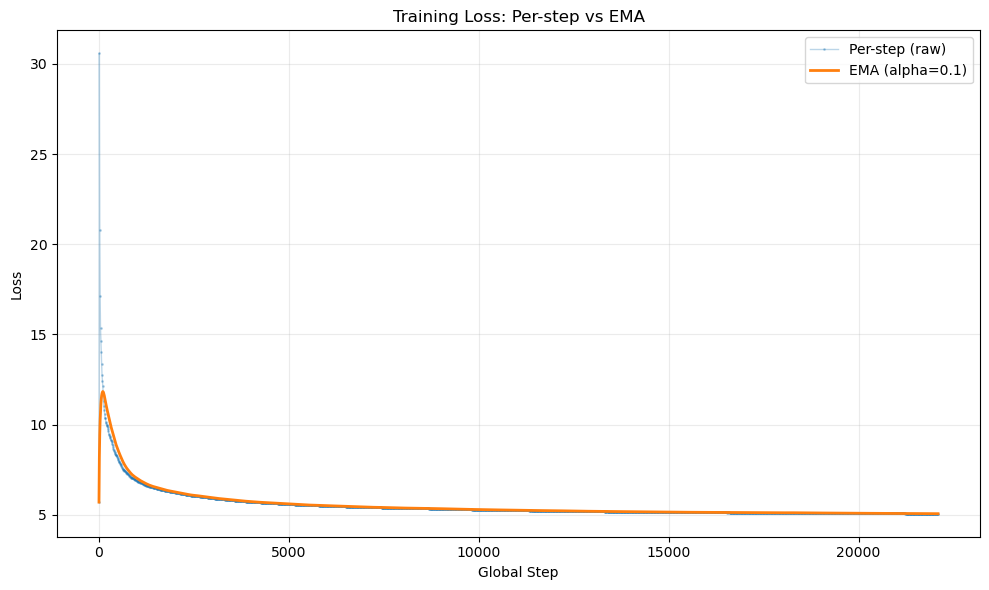

In [17]:
# ==========================================
# FIXED PLOTTING CODE
# ==========================================

# 1. Sort by step only
all_records = sorted(all_records, key=lambda x: x[0])

# 2. Unpack only 2 values (Step, Loss)
steps, losses = zip(*all_records)

# 3. Compute EMA
losses_ema = ema(losses, alpha=ALPHA)

# ---- plot ----
plt.figure(figsize=(10, 6))

# Plot raw steps
plt.plot(
    steps, losses,
    marker=".", linestyle="-",
    linewidth=1, markersize=2,
    alpha=0.3,
    label="Per-step (raw)"
)

# Plot EMA
plt.plot(
    steps, losses_ema,
    linewidth=2,
    label=f"EMA (alpha={ALPHA})"
)

plt.xlabel("Global Step")
plt.ylabel("Loss")
plt.title("Training Loss: Per-step vs EMA")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Pretrain

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_log(csv_path, plot_mode="step", show_system_stats=False, title=None):
    """
    Args:
        csv_path: Path to the CSV file.
        plot_mode: 'step' (default) or 'epoch'.
        show_system_stats: Boolean. If False, only plots the Loss graph.
        title: String. Custom title for the plot. If None, uses a default.
    """
    # 1. Load Data
    df = pd.read_csv(csv_path)
    
    # Calculate EMA for smoother lines
    df['loss_ema'] = df['loss'].ewm(alpha=0.1).mean()

    # ==========================================
    # IF/ELSE: Switch X-Axis Data
    # ==========================================
    if plot_mode == "epoch":
        # Calculate "Fractional Epoch" so points don't stack vertically
        # Formula: Epoch_Int + (Iter / Max_Iter)
        max_itr = df['itr'].max() or 1  # avoid div by zero
        x_data = df['epoch'] + (df['itr'] / max_itr)
        x_label = "Epoch"
    else:
        # Default: Use the iteration/step counter
        x_data = df['itr']
        x_label = "Global Step"

    # ==========================================
    # PLOTTING
    # ==========================================
    
    if show_system_stats:
        # Create 2 stacked plots sharing the X axis
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    else:
        # Create 1 single plot
        fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
        ax2 = None

    # --- Plot 1: Loss ---
    ax1.plot(x_data, df['loss'], 
             marker='.', color='gray', alpha=0.3, label='Raw Loss')
    ax1.plot(x_data, df['loss_ema'], 
             color='blue', linewidth=2, label='EMA Loss')
    
    ax1.set_ylabel('Loss')
    
    # Set Title (Custom or Default)
    if title:
        ax1.set_title(title)
    else:
        ax1.set_title(f'Training Progress (by {x_label})')

    ax1.legend()
    ax1.grid(True, alpha=0.25)

    # --- Plot 2: Timings (Optional) ---
    if show_system_stats and ax2 is not None:
        ax2.plot(x_data, df['iter-time(ms)'], label='Total Time', color='black', linestyle='--')
        ax2.plot(x_data, df['gpu-time(ms)'], label='GPU Time', color='green', alpha=0.6)
        
        # Clip the Y-axis to remove the "startup" spike
        y_cap = df['iter-time(ms)'].quantile(0.95) * 1.2
        ax2.set_ylim(0, y_cap)
        
        ax2.set_ylabel('Time (ms)')
        ax2.set_xlabel(x_label)
        ax2.legend()
        ax2.grid(True, alpha=0.25)
    else:
        # If single plot, set label on ax1
        ax1.set_xlabel(x_label)

    plt.tight_layout()
    plt.show()

In [42]:
! aws s3 cp s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/55/training_folder/log_r7.csv ./echojepa-l-pretrain-cont90.csv

download: s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/55/training_folder/log_r7.csv to ./echojepa-l-pretrain.csv


In [46]:
! aws s3 cp s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_125/training_folder/log_r7.csv ./echojepa-l-pretrain-cont90.csv 

download: s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_125/training_folder/log_r7.csv to ./echojepa-l-pretrain-cont90.csv


In [ ]:
! aws s3 cp s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_129/training_folder/log_r7.csv ./echojepa-l-pretrain-cont120.csv 

In [69]:
! aws s3 cp s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_137/training_folder/log_r7.csv ./echojepa-l-pretrain-cont130.csv 

download: s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_137/training_folder/log_r7.csv to ./echojepa-l-pretrain-cont130.csv


In [92]:
! aws s3 cp s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_148/training_folder/log_r7.csv ./echojepa-l-pretrain-cont144.csv 

download: s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_148/training_folder/log_r7.csv to ./echojepa-l-pretrain-cont144.csv


In [110]:
! aws s3 cp s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_149/training_folder/log_r7.csv ./echojepa-l-pretrain-cont150.csv 

download: s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_149/training_folder/log_r7.csv to ./echojepa-l-pretrain-cont150.csv


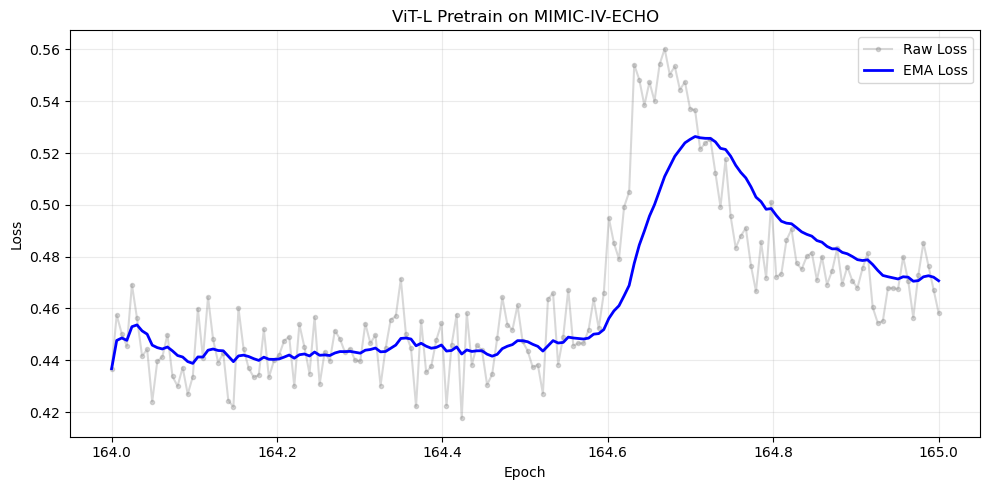

In [111]:
plot_training_log("echojepa-l-pretrain-cont150.csv", plot_mode="epoch", title="ViT-L Pretrain on MIMIC-IV-ECHO")

In [128]:
! aws s3 cp s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_150/training_folder/log_r7.csv ./echojepa-l-pretrain-cont160.csv 

download: s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_mimic_pretrain_150/training_folder/log_r7.csv to ./echojepa-l-pretrain-cont160.csv


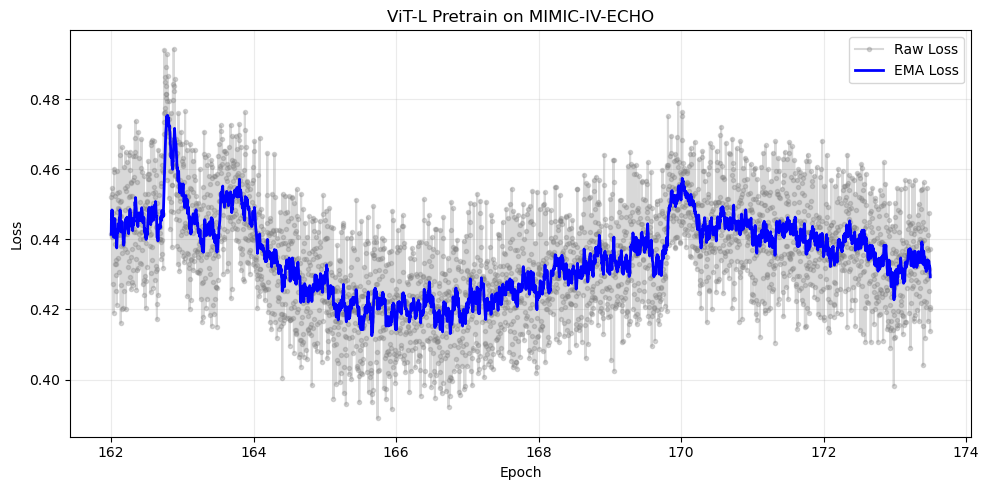

In [129]:
plot_training_log("echojepa-l-pretrain-cont160.csv", plot_mode="epoch", title="ViT-L Pretrain on MIMIC-IV-ECHO")

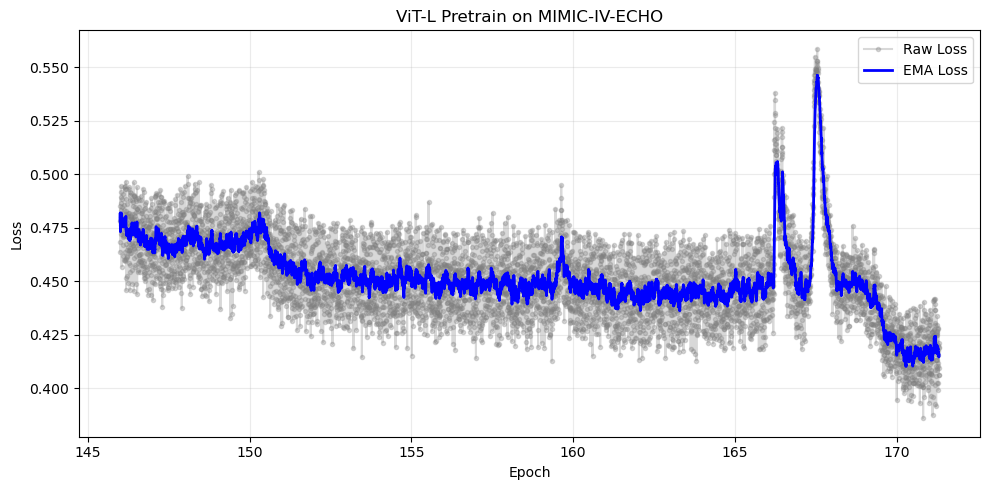

In [93]:
plot_training_log("echojepa-l-pretrain-cont144.csv", plot_mode="epoch", title="ViT-L Pretrain on MIMIC-IV-ECHO")

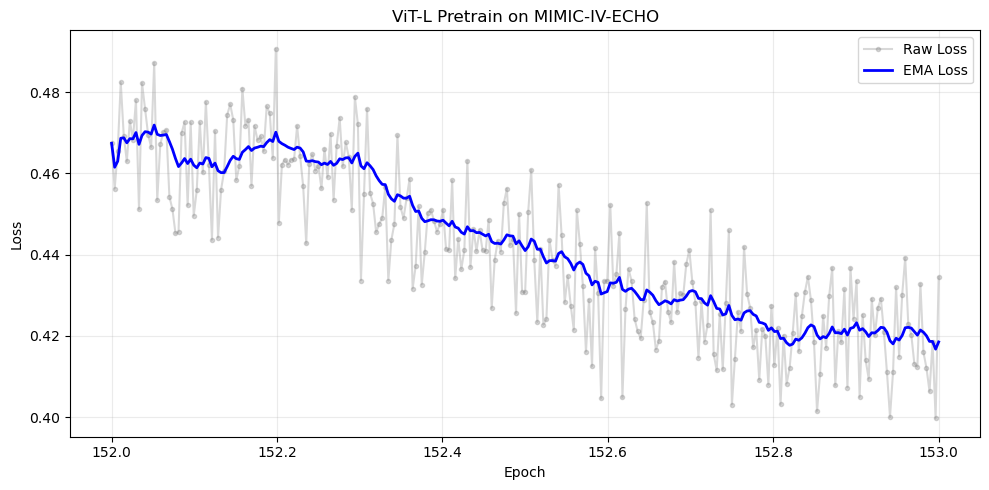

In [73]:
plot_training_log("echojepa-l-pretrain-cont150.csv", plot_mode="epoch", title="ViT-L Pretrain on MIMIC-IV-ECHO")

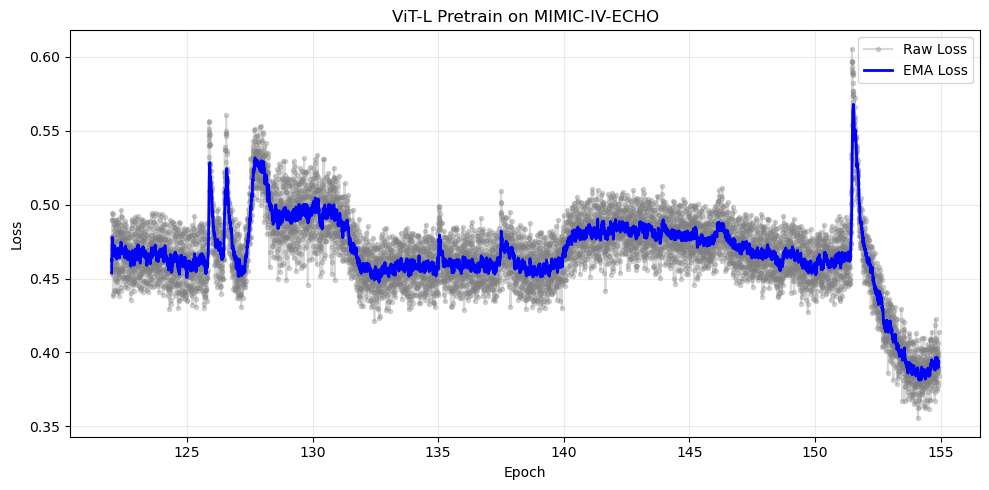

In [70]:
plot_training_log("echojepa-l-pretrain-cont130.csv", plot_mode="epoch", title="ViT-L Pretrain on MIMIC-IV-ECHO")

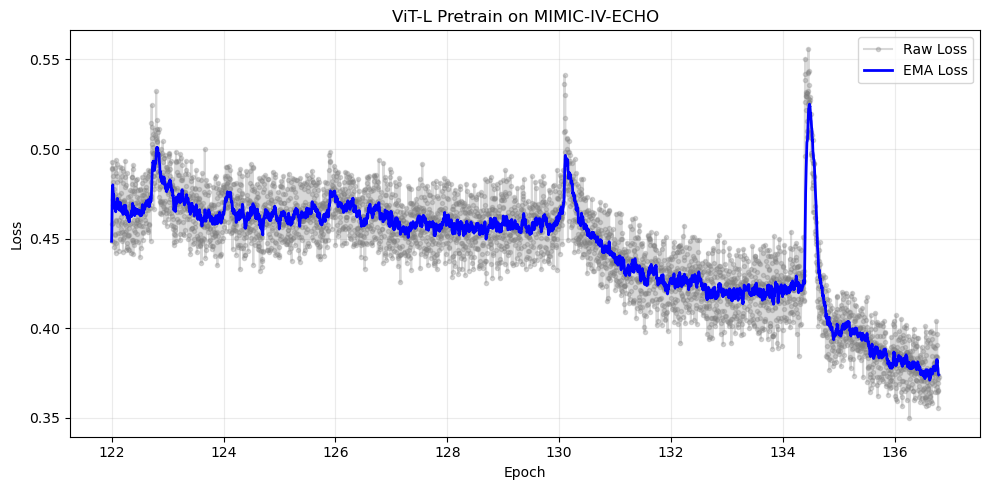

In [54]:
plot_training_log("echojepa-l-pretrain-cont120.csv", plot_mode="epoch", title="ViT-L Pretrain on MIMIC-IV-ECHO")

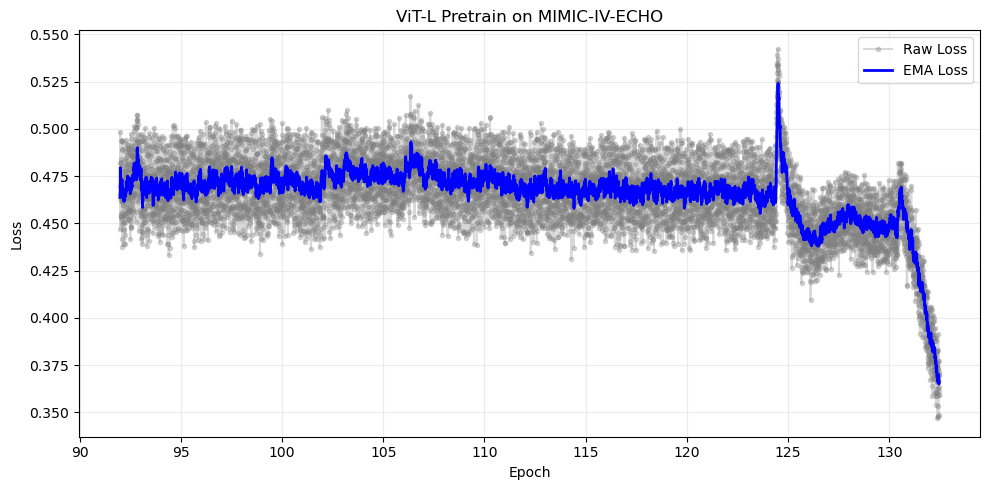

In [47]:
plot_training_log("echojepa-l-pretrain-cont90.csv", plot_mode="epoch", title="ViT-L Pretrain on MIMIC-IV-ECHO")

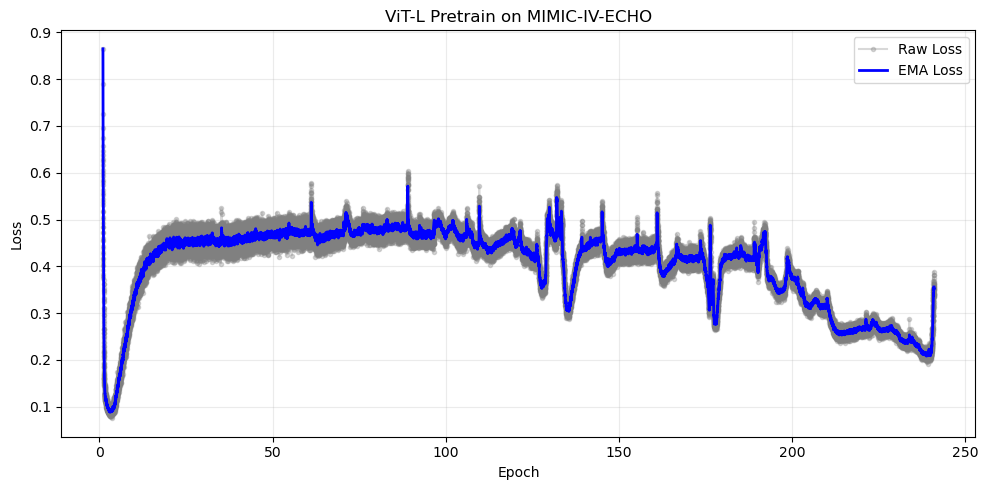

In [43]:
plot_training_log("echojepa-l-pretrain.csv", plot_mode="epoch", title="ViT-L Pretrain on MIMIC-IV-ECHO")

In [39]:
! aws s3 cp s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_cooldown_117/training_folder/log_r7.csv ./echojepa-l-cooldown-ep20.csv

download: s3://sagemaker-hyperpod-lifecycle-495467399120-usw2/vjepa2-artifacts/runs/vjepa_cooldown_117/training_folder/log_r7.csv to ./echojepa-l-cooldown-ep20.csv


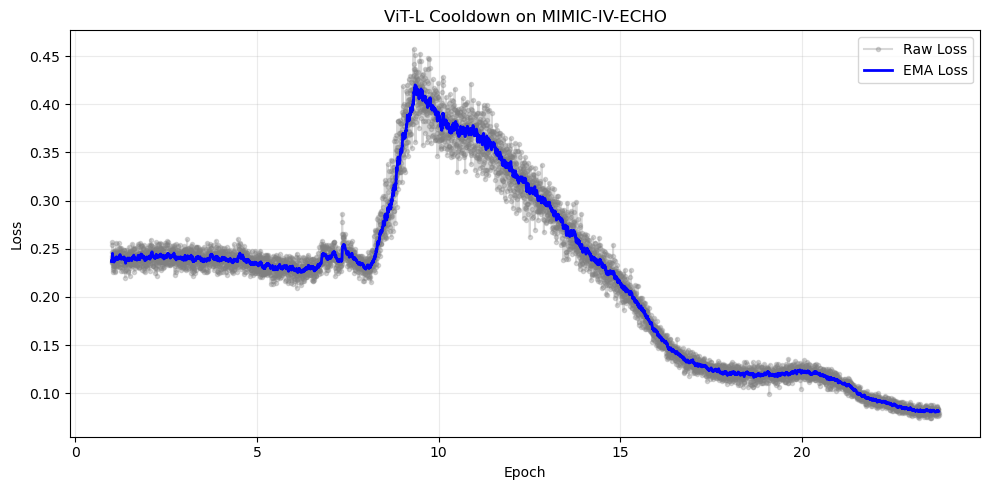

In [40]:
plot_training_log("echojepa-l-cooldown-ep20.csv", plot_mode="epoch", title="ViT-L Cooldown on MIMIC-IV-ECHO")

# Collapse Check

In [ ]:
import torch

encoder.eval()
with torch.no_grad():
    # Grab a batch
    features = encoder(sample_batch)  # [B, N, D]
    
    # Check 1: Feature std (should NOT be near zero)
    print(f"Feature std: {features.std().item():.4f}")
    
    # Check 2: Per-sample similarity (should NOT be ~1.0)
    flat = features.mean(dim=1)  # [B, D]
    flat_norm = flat / flat.norm(dim=1, keepdim=True)
    cos_sim = (flat_norm @ flat_norm.T).mean().item()
    print(f"Mean pairwise cosine sim: {cos_sim:.4f}")